# # Thesis Analysis: Color Evolution & Art Styles
# This notebook calculates statistical trends for color uniformization.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy

# Load data
# df = pd.read_csv("data/new_game_data.csv")

df = pd.read_csv('C:\\Users\\nina\\Documents\\UNI\\SEM\\thesis\\new_git\\masterThesis\\coding\\game_color_analysis\\data\\test_game_data.csv')

# ## 1. Defining Color Diversity (Entropy)
# We calculate how "spread out" colors are in the RGB cube for a given year.
# A lower entropy suggests 'Uniformization'.

C:\Users\nina\AppData\Local\Temp\ipykernel_34044\1466863606.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  diversity_series = df.groupby('Year').apply(calculate_year_entropy)


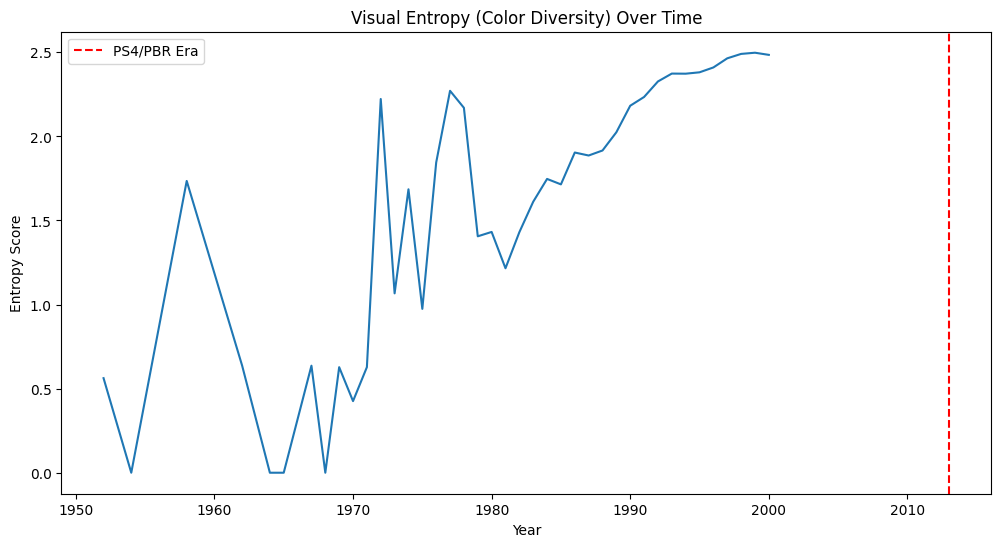

In [3]:
def calculate_year_entropy(group):
    # Flatten all R,G,B values for the year into a single distribution
    all_colors = group[['C1_R', 'C1_G', 'C1_B']].values.flatten()
    hist, _ = np.histogram(all_colors, bins=16, range=(0, 256), density=True)
    return entropy(hist + 1e-9) # Add tiny value to avoid log(0)

diversity_series = df.groupby('Year').apply(calculate_year_entropy)

plt.figure(figsize=(12, 6))
sns.lineplot(x=diversity_series.index, y=diversity_series.values)
plt.title("Visual Entropy (Color Diversity) Over Time")
plt.ylabel("Entropy Score")
plt.axvline(x=2013, color='r', linestyle='--', label='PS4/PBR Era')
plt.legend()
plt.show()

## 2. Genre vs. Color (The "Horror" vs "Action" Convergence)
Does a genre have a "Signature"?

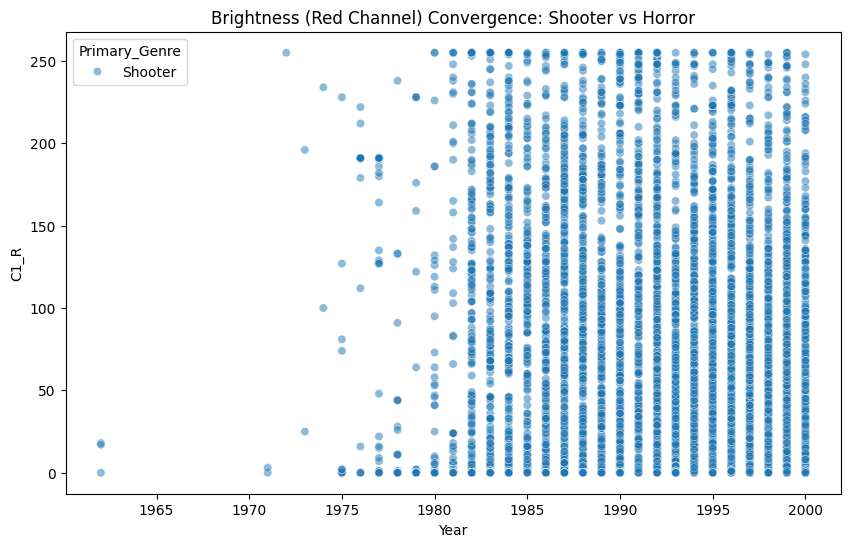

In [4]:
# Filter for two major genres
genre_a = "Shooter"
genre_b = "Horror"

subset = df[df['Genres'].str.contains(f"{genre_a}|{genre_b}", na=False)].copy()
subset['Primary_Genre'] = subset['Genres'].apply(lambda x: genre_a if genre_a in x else genre_b)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=subset, x='Year', y='C1_R', hue='Primary_Genre', alpha=0.5)
plt.title(f"Brightness (Red Channel) Convergence: {genre_a} vs {genre_b}")
plt.show()

## 3. Technology Milestones vs. Saturation
# Analyzing if modern tech (PBR/RayTracing) makes games more "Grey/Realistic".

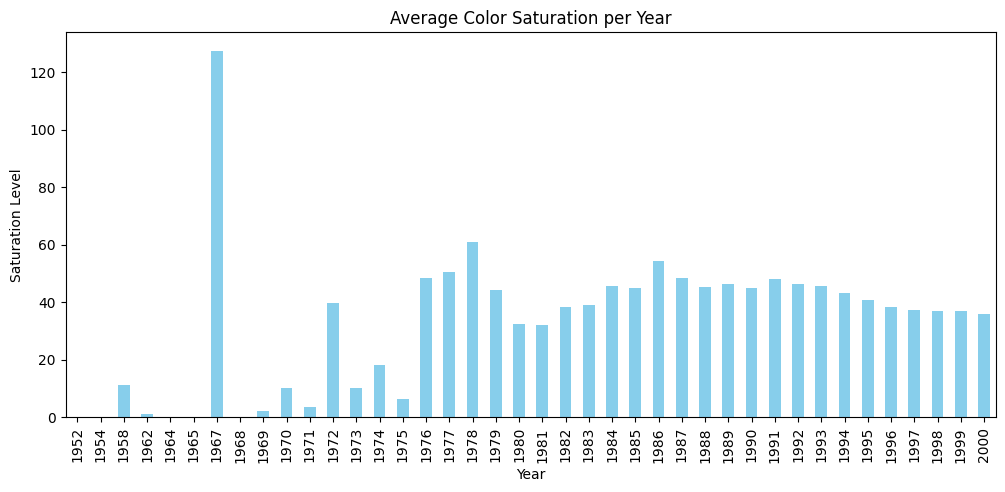

In [5]:
# Calculate saturation approximation: max(RGB) - min(RGB)
df['Saturation'] = df[['C1_R', 'C1_G', 'C1_B']].max(axis=1) - df[['C1_R', 'C1_G', 'C1_B']].min(axis=1)

tech_trends = df.groupby('Year')['Saturation'].mean()

plt.figure(figsize=(12, 5))
tech_trends.plot(kind='bar', color='skyblue')
plt.title("Average Color Saturation per Year")
plt.ylabel("Saturation Level")
plt.show()

# ## 4. Developer Signatures
# Which developers dominate specific palettes?

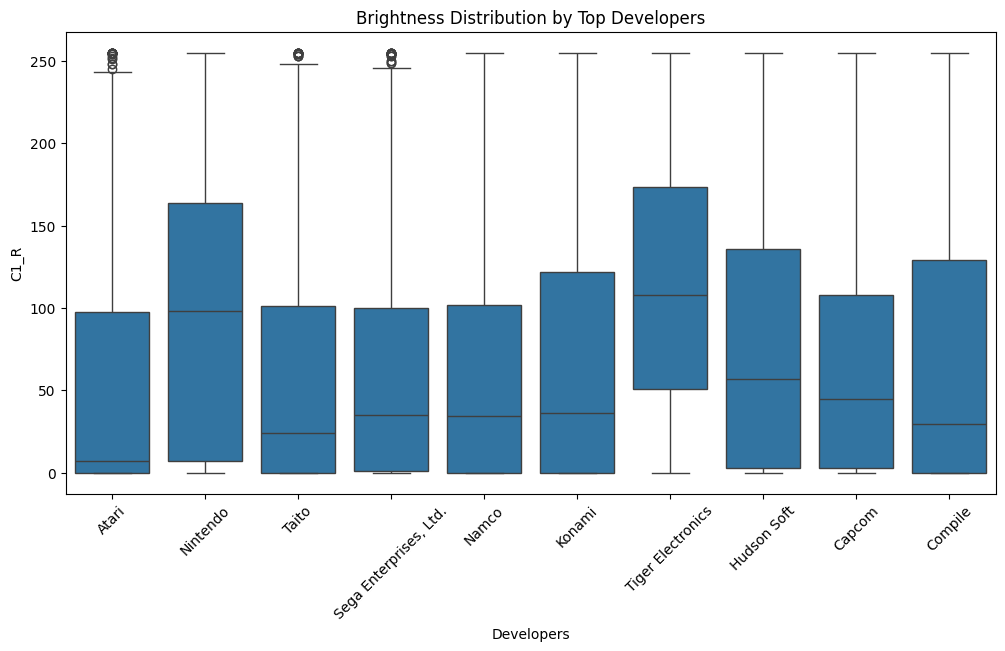

In [6]:
top_devs = df['Developers'].value_counts().nlargest(10).index
dev_colors = df[df['Developers'].isin(top_devs)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=dev_colors, x='Developers', y='C1_R')
plt.xticks(rotation=45)
plt.title("Brightness Distribution by Top Developers")
plt.show()